In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('Algerian_forest_fires_cleaned_dataset.csv')

In [66]:
df.head()

,Day,Month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [68]:
df['Classes'].value_counts()

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [70]:
df_copy = df.drop(['Day','Month','year'],axis=1)

In [72]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


### Encoding the categories in the classes

In [75]:
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [77]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


In [79]:
df_copy['Classes'].value_counts()

Classes
1    137
0    106
Name: count, dtype: int64

### 1. Density plot for all features

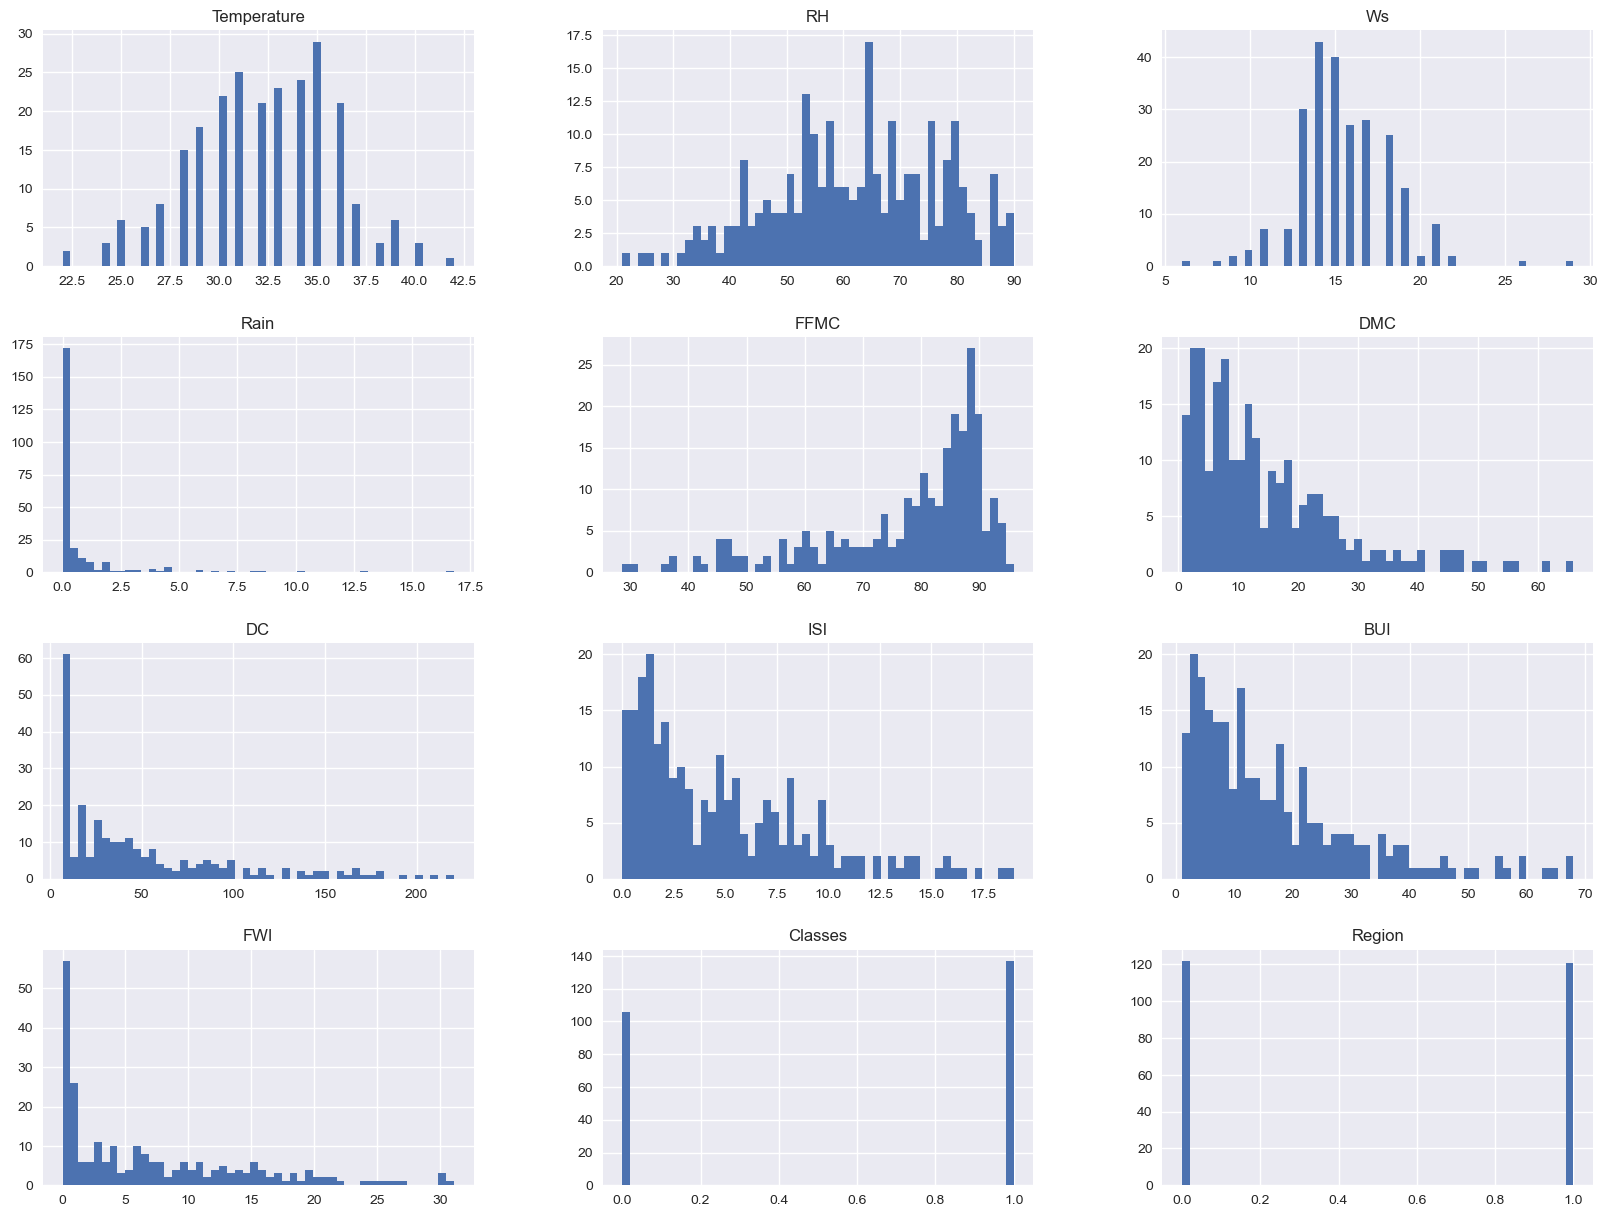

In [84]:
plt.style.use('seaborn-v0_8')
df_copy.hist(bins=50,figsize=(20,15))
plt.show()

Text(0.5, 1.0, 'Classes Distribtuion')

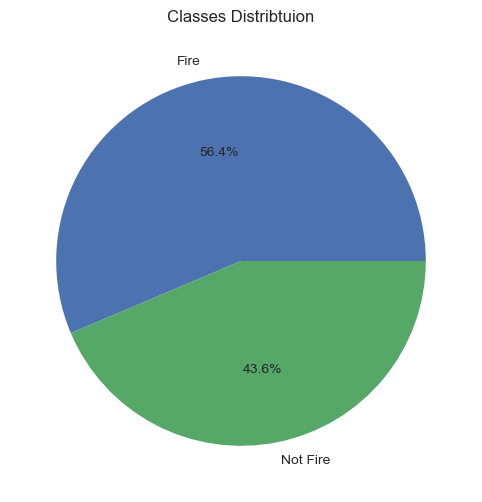

In [100]:
plt.figure(figsize=(10,6))
plt.pie(df_copy['Classes'].value_counts(),labels=['Fire','Not Fire'],autopct='%1.1f%%')
plt.title('Classes Distribtuion')

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

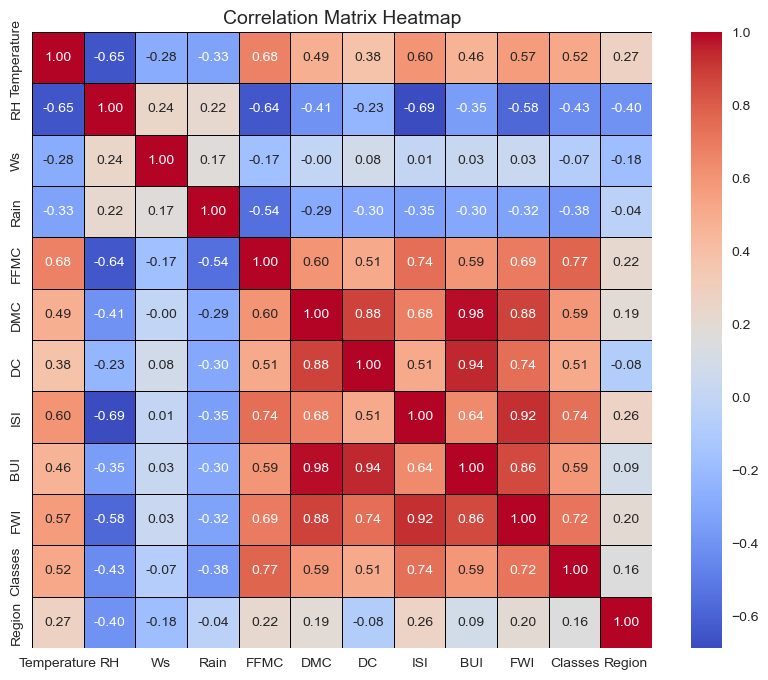

In [110]:
plt.figure(figsize=(10,8))  # makes it readable

sns.heatmap(
    df_copy.corr(), 
    annot=True,          # ⭐ shows correlation values
    fmt=".2f",           # show 2 decimal places
    cmap="coolwarm",     # color theme
    linewidths=0.5,      # lines between boxes
    linecolor='black'
)

plt.title("Correlation Matrix Heatmap", fontsize=14)

<Axes: ylabel='FWI'>

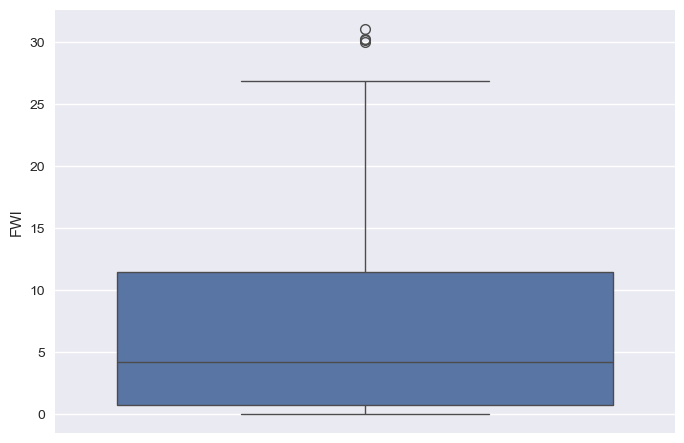

In [112]:
sns.boxplot(df['FWI'])

### Monthly fire analysis

In [115]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'),'not fire','fire')

Text(0.5, 1.0, 'Month Fire Analysis')

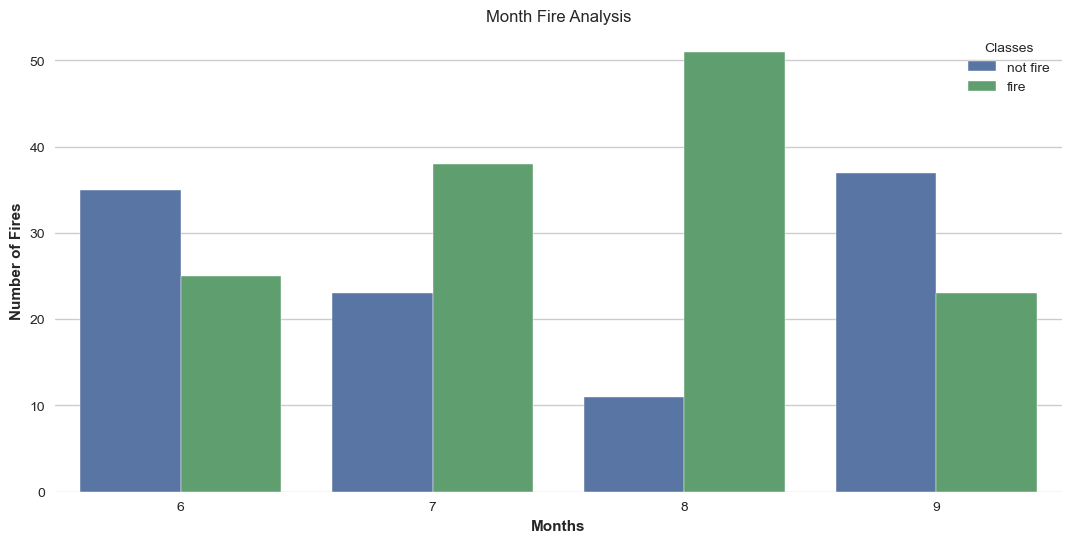

In [123]:
dftemp = df.loc[df['Region']==0]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='Month',hue='Classes',data=df)
plt.xlabel('Months',weight='bold')
plt.ylabel('Number of Fires',weight='bold')
plt.title('Monthly Fire Analysis on Bejaia Region')

Text(0.5, 1.0, 'Monthly Fire Analysis on Sidi-Bel Abbes Region')

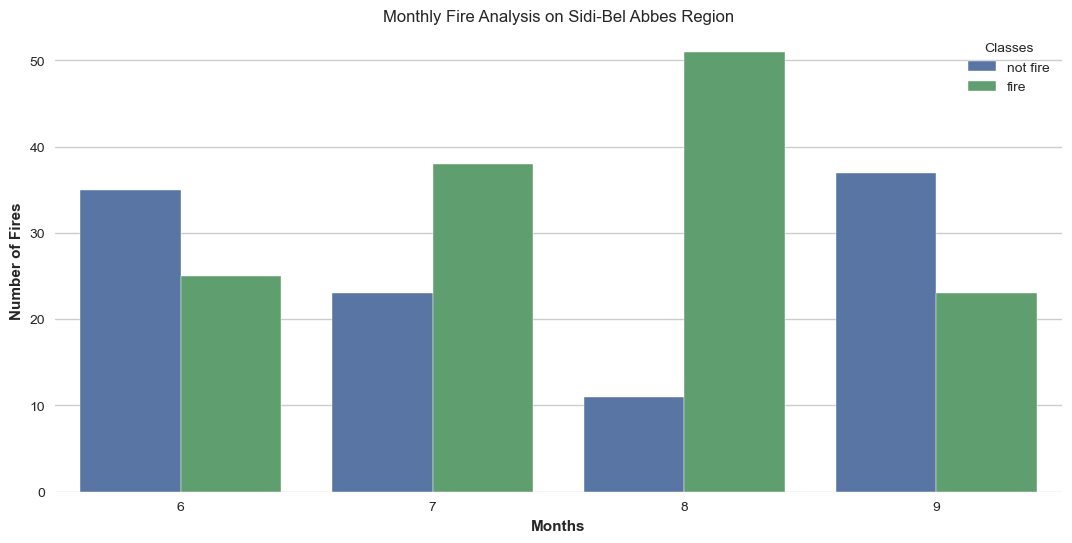

In [127]:
dftemp = df.loc[df['Region']==1]
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='Month',hue='Classes',data=df)
plt.xlabel('Months',weight='bold')
plt.ylabel('Number of Fires',weight='bold')
plt.title('Monthly Fire Analysis on Sidi-Bel Abbes Region')

# Observation
It's observed that August and September had the most number of forest fires for both regions . And from the above plot of months , we can understand few things most of the fires happened in August and very high fires happened in only 3 months June , July and Augus Less fires was on September